Código de corrección de Bit-flip


Resultados: {'1': 260, '0': 252}


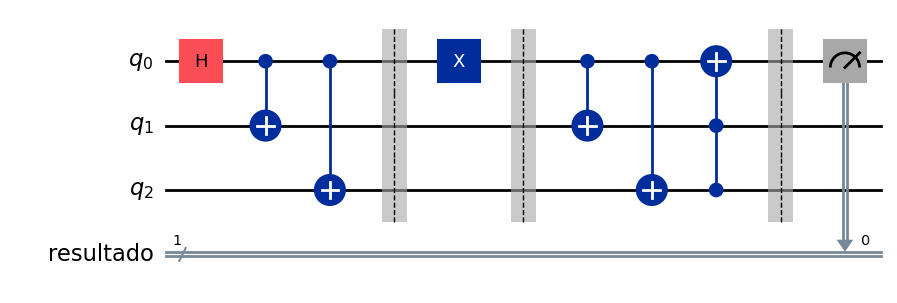

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer

# 1. Configuración: Solo necesitamos 3 qubits y 1 bit clásico para el resultado final
q = QuantumRegister(3, 'q')
c = ClassicalRegister(1, 'resultado')

bit_flip_toffoli = QuantumCircuit(q, c)

# --- Preparación del estado (Codificación) ---
bit_flip_toffoli.h(q[0])
bit_flip_toffoli.cx(q[0], q[1])
bit_flip_toffoli.cx(q[0], q[2])

bit_flip_toffoli.barrier() # Separador visual

# --- Simular error de Bit-flip ---
# Vamos a simular que el error ocurre en el qubit 0 para probar la Toffoli
bit_flip_toffoli.x(q[0]) 

bit_flip_toffoli.barrier()

# --- Corrección con Puerta Toffoli (Decodificación y Corrección) ---
# Usamos puertas CX para comparar los estados
bit_flip_toffoli.cx(q[0], q[1])
bit_flip_toffoli.cx(q[0], q[2])

# La puerta Toffoli (ccx) corrige q[0] si q[1] y q[2] son 1
bit_flip_toffoli.ccx(q[2], q[1], q[0])

bit_flip_toffoli.barrier()

# --- Medida final ---
# Si la corrección funcionó, q[0] debería volver a su estado de superposición original
bit_flip_toffoli.measure(q[0], c[0])

# 2. Ejecución
backend = Aer.get_backend('qasm_simulator')
job = backend.run(bit_flip_toffoli, shots=512)
counts = job.result().get_counts()

print('\nResultados:', counts)

# 3. Dibujar el esquema
# Si estás en VS Code, esto generará la imagen del circuito
bit_flip_toffoli.draw(output='mpl')

Codigo de corrección de Phase-flip


Resultados: {'1': 524, '0': 500}


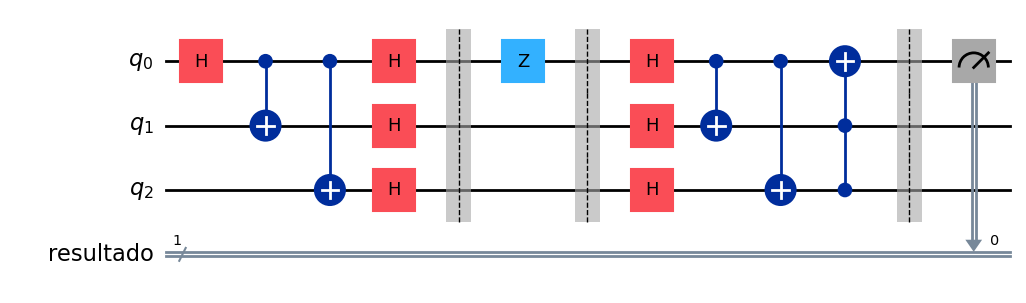

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer

# 1. Configuración: Solo necesitamos 3 qubits y 1 bit clásico para el resultado final
q = QuantumRegister(3, 'q')
c = ClassicalRegister(1, 'resultado')

phase_flip_toffoli = QuantumCircuit(q, c)

# --- Preparación del estado (Codificación) ---
phase_flip_toffoli.h(q[0])
phase_flip_toffoli.cx(q[0], q[1])
phase_flip_toffoli.cx(q[0], q[2])


phase_flip_toffoli.h(q[0]) 
phase_flip_toffoli.h(q[1]) 
phase_flip_toffoli.h(q[2]) 



phase_flip_toffoli.barrier() # Separador visual

# Simular error de Phase-flip 
# Vamos a simular que el error ocurre en el qubit 0 para probar la Toffoli
phase_flip_toffoli.z(q[0]) 

phase_flip_toffoli.barrier()



phase_flip_toffoli.h(q[0]) 
phase_flip_toffoli.h(q[1]) 
phase_flip_toffoli.h(q[2]) 


# Usamos puertas CX para comparar los estados
phase_flip_toffoli.cx(q[0], q[1])
phase_flip_toffoli.cx(q[0], q[2])

# La puerta Toffoli (ccx) corrige q[0] si q[1] y q[2] son 1
phase_flip_toffoli.ccx(q[2], q[1], q[0])

phase_flip_toffoli.barrier()

# Medida final 
# Si la corrección funcionó, q[0] debería volver a su estado de superposición original
phase_flip_toffoli.measure(q[0], c[0])

# 2. Ejecución
backend = Aer.get_backend('qasm_simulator')
job = backend.run(phase_flip_toffoli, shots=1024)
counts = job.result().get_counts()

print('\nResultados:', counts)


phase_flip_toffoli.draw(output='mpl')